In [1]:
%load_ext autoreload
%autoreload 0
%matplotlib inline

In [3]:
import re,sys,os
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

# Set font to Arial
matplotlib.rcParams['font.family'] = 'Arial'

# Optional: Set PDF to embed fonts (for Illustrator editing)
matplotlib.rcParams['pdf.fonttype'] = 42  # TrueType fonts for better editing


In [5]:
DATA_DIR = Path(r"E:\lab\cptac-prostate\runs\20260401_mspycloud_cptac_protein_tmt_pca")
GG2_DIR = DATA_DIR / "genes_protein_GG2_vs_normal"
GG3_DIR = DATA_DIR / "genes_protein_GG3_vs_normal"
GG4_DIR = DATA_DIR / "genes_protein_GG4_vs_normal"
T_DR = DATA_DIR / "genes_protein_tumor_vs_normal"

print(GG2_DIR.exists(), GG3_DIR.exists(), GG4_DIR.exists(), T_DR.exists())

True True True True


In [7]:
GG2_UP_GENES_PATH = GG2_DIR / "S-U_genes.txt"
gg2_up_genes = pd.read_csv(GG2_UP_GENES_PATH, header=None)[0].tolist()
print(gg2_up_genes[:5], len(gg2_up_genes))

['CAPN15', 'COMP', 'GDF15', 'FMO5', 'UTP3'] 56


In [ ]:
GG3_UP_GENES_PATH = GG3_DIR / "S-U_genes.txt"
gg3_up_genes = pd.read_csv(GG3_UP_GENES_PATH, header=None)[0].tolist()


['CD74', 'CAPN15', 'COMP', 'GAR1', 'SRSF6'] 102


In [9]:
GG4_UP_GENES_PATH = GG4_DIR / "S-U_genes.txt"
gg4_up_genes = pd.read_csv(GG4_UP_GENES_PATH, header=None)[0].tolist()
print(gg4_up_genes[:5], len(gg4_up_genes))

['CHPF2', 'FAP', 'CAPN15', 'FBL', 'COMP'] 109


In [10]:
T_UP_GENES_PATH = T_DR / "S-U_genes.txt"
t_up_genes = pd.read_csv(T_UP_GENES_PATH, header=None)[0].tolist()
print(t_up_genes[:5], len(t_up_genes))

['CAPN15', 'COMP', 'GAR1', 'GDF15', 'UTP3'] 59


In [11]:
gg2_up_genes_set = set(gg2_up_genes)
gg3_up_genes_set = set(gg3_up_genes)
gg4_up_genes_set = set(gg4_up_genes)
t_up_genes_set = set(t_up_genes)

<Figure size 800x800 with 0 Axes>

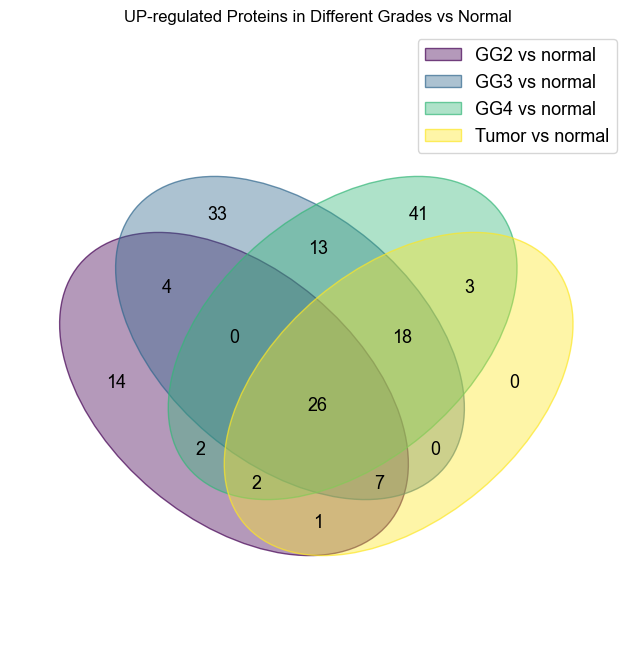

In [13]:
import matplotlib.pyplot as plt
from venn import venn

# 4 个集合
sets = {
    "GG2 vs normal": gg2_up_genes_set,
    "GG3 vs normal": gg3_up_genes_set,
    "GG4 vs normal": gg4_up_genes_set,
    "Tumor vs normal": t_up_genes_set
}

plt.figure(figsize=(8, 8))
venn(sets)
plt.title("UP-regulated Proteins in Different Grades vs Normal")
plt.show()

In [14]:
from itertools import combinations
import pandas as pd


sets = {
    "GG2": gg2_up_genes_set,
    "GG3": gg3_up_genes_set,
    "GG4": gg4_up_genes_set,
    "All": t_up_genes_set
}

set_names = list(sets.keys())

results = []

# 遍历所有非空组合
for r in range(1, len(set_names) + 1):
    for combo in combinations(set_names, r):
        combo = tuple(combo)

        # 先求这些集合的交集
        intersection = set.intersection(*(sets[name] for name in combo))

        # 再排除掉不在 combo 中、但出现在其他集合里的元素
        other_names = [name for name in set_names if name not in combo]
        exclusive = intersection.copy()
        for other in other_names:
            exclusive -= sets[other]

        results.append({
            "combination": "&".join(combo),
            "n_sets": len(combo),
            "count": len(exclusive),
            "elements": sorted(exclusive)
        })

df = pd.DataFrame(results)

print("=== 按逻辑顺序 ===")
df_logic = df.sort_values(["n_sets", "combination"]).reset_index(drop=True)
print(df_logic)

print("\n=== 按 count 从大到小排序 ===")
df_count = df.sort_values(["count", "n_sets", "combination"], ascending=[False, True, True]).reset_index(drop=True)
print(df_count)

=== 按逻辑顺序 ===
        combination  n_sets  count  \
0               All       1      0   
1               GG2       1     14   
2               GG3       1     33   
3               GG4       1     41   
4           GG2&All       2      1   
5           GG2&GG3       2      4   
6           GG2&GG4       2      2   
7           GG3&All       2      0   
8           GG3&GG4       2     13   
9           GG4&All       2      3   
10      GG2&GG3&All       3      7   
11      GG2&GG3&GG4       3      0   
12      GG2&GG4&All       3      2   
13      GG3&GG4&All       3     18   
14  GG2&GG3&GG4&All       4     26   

                                             elements  
0                                                  []  
1   [C15orf48, DAPK2, FMO5, GJB1, HEXB, MAML3, MGA...  
2   [ABHD10, ACADSB, ALCAM, ALDH6A1, ALG8, BDH1, C...  
3   [ACAD9, ALDH18A1, ANP32A, ANP32B, ARID3A, ASPN...  
4                                             [FABP5]  
5                    [FAM210B, PDIA4, SPI

In [15]:
df_logic

,combination,n_sets,count,elements
0,All,1,0,[]
1,GG2,1,14,"[C15orf48, DAPK2, FMO5, GJB1, HEXB, MAML3, MGA..."
2,GG3,1,33,"[ABHD10, ACADSB, ALCAM, ALDH6A1, ALG8, BDH1, C..."
3,GG4,1,41,"[ACAD9, ALDH18A1, ANP32A, ANP32B, ARID3A, ASPN..."
4,GG2&All,2,1,[FABP5]
5,GG2&GG3,2,4,"[FAM210B, PDIA4, SPINT1, UBE2E2]"
6,GG2&GG4,2,2,"[AGR2, MYO6]"
7,GG3&All,2,0,[]
8,GG3&GG4,2,13,"[COA7, CRAT, FMC1, GRPEL1, HNRNPA1, MYEF2, NOP..."
9,GG4&All,2,3,"[SFRP4, THBS4, UBN1]"


In [17]:
DATA_DIR = Path(r"E:\lab\cptac-prostate\runs\20260401_quality_control")
files = [i for i in DATA_DIR.iterdir() if i.is_file()]
files = [i for i in files if re.search(r"mspycloud_Global_DDA_TMT_log2ratio",i.stem, re.IGNORECASE) \
    and not re.search(r"tumor_purity_corrected",i.stem, re.IGNORECASE)]
data_path = files[0]
protein_header_cols = ["Protein.Group.Accessions"]
data = pd.read_csv(data_path,sep="\t").set_index(protein_header_cols)
data_nomiss = data.dropna()

In [18]:
data

,Reference Sample 1,C3L-05292_T,C3L-09383_T,CHTN-43798_T,C3L-06261_N,C3L-08811_T,C3L-06506_N,C3L-07804_T,C3L-06595_T,C3L-06742_T,...,CHTN-44966_T,C3L-11192_N,C3L-08805_T,C3L-09760_T,C3L-08444_T,C3L-08291_T,C3L-10583_T,C3L-07877_T,C3L-08377_T,C3L-08736_T
Protein.Group.Accessions,,,,,,,,,,,,,,,,,,,,,
ENSP00000000233|ENST00000000233|ENSG00000004059|ARF5 ADP ribosylation factor 5,0.0,0.077017,-0.187993,-0.137950,-0.255903,0.235679,-0.122157,0.049047,-0.150472,0.090129,...,0.177651,-0.184215,-0.495843,0.065143,0.050001,0.262834,-0.221609,0.084544,-0.024535,0.266896
"ENSP00000000412|ENST00000000412|ENSG00000003056|M6PR mannose-6-phosphate receptor, cation dependent",0.0,0.122390,0.036646,0.179340,0.038353,0.361856,0.023644,-0.226568,-0.218785,-0.029380,...,-0.210005,-0.509339,0.323025,0.112554,-0.003882,-0.364879,-0.290935,0.175473,0.113948,0.242116
ENSP00000001008|ENST00000001008|ENSG00000004478|FKBP4 FKBP prolyl isomerase 4,0.0,-0.158774,-0.185559,-0.186552,-0.403156,0.400005,-0.286488,-0.581658,-0.184171,0.472634,...,-0.235445,-0.561989,-0.306163,0.162003,0.084839,0.157711,-0.421211,-0.058981,-0.186794,0.220484
ENSP00000002125|ENST00000002125|ENSG00000003509|NDUFAF7 NADH:ubiquinone oxidoreductase complex assembly factor 7,0.0,-0.007247,0.085730,-0.037076,-0.063520,0.155436,-0.019618,-0.203342,0.050553,-0.125149,...,-0.261797,0.020816,0.195666,0.066049,0.017390,-0.083763,0.028189,-0.052304,-0.023878,0.302151
ENSP00000002165|ENST00000002165|ENSG00000001036|FUCA2 alpha-L-fucosidase 2,0.0,0.075815,0.295018,0.097095,-0.751552,0.072959,-0.744420,-1.052637,-0.236417,0.532446,...,0.024258,-0.138183,-0.132877,0.102094,-0.293056,0.623585,-0.611337,-0.503879,0.224542,0.707597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSP00000307014|ENST00000305748|ENSG00000186049|KRT73 keratin 73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.705524,1.032750,-0.274949,-0.305077,0.167676,-0.272981,0.215760,0.833478,0.328482,-0.000854
"ENSP00000312070|ENST00000308177|ENSG00000240184|PCDHGC3 protocadherin gamma subfamily C, 3",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.016368,0.176268,0.339498,0.119363,0.172382,-0.108952,0.503057,0.065289,0.034634,-0.416416
ENSP00000452370|ENST00000557607|ENSG00000100722|ZC3H14 zinc finger CCCH-type containing 14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.492035,0.539346,-0.074879,-0.652922,-0.225059,0.028898,0.282637,-0.544384,0.020144,0.257734


In [20]:
data2 = data.copy()
data2.index = [ i.split("|")[-1].split(" ")[0] for i in data.index ]

In [21]:
data2

,Reference Sample 1,C3L-05292_T,C3L-09383_T,CHTN-43798_T,C3L-06261_N,C3L-08811_T,C3L-06506_N,C3L-07804_T,C3L-06595_T,C3L-06742_T,...,CHTN-44966_T,C3L-11192_N,C3L-08805_T,C3L-09760_T,C3L-08444_T,C3L-08291_T,C3L-10583_T,C3L-07877_T,C3L-08377_T,C3L-08736_T
ARF5,0.0,0.077017,-0.187993,-0.137950,-0.255903,0.235679,-0.122157,0.049047,-0.150472,0.090129,...,0.177651,-0.184215,-0.495843,0.065143,0.050001,0.262834,-0.221609,0.084544,-0.024535,0.266896
M6PR,0.0,0.122390,0.036646,0.179340,0.038353,0.361856,0.023644,-0.226568,-0.218785,-0.029380,...,-0.210005,-0.509339,0.323025,0.112554,-0.003882,-0.364879,-0.290935,0.175473,0.113948,0.242116
FKBP4,0.0,-0.158774,-0.185559,-0.186552,-0.403156,0.400005,-0.286488,-0.581658,-0.184171,0.472634,...,-0.235445,-0.561989,-0.306163,0.162003,0.084839,0.157711,-0.421211,-0.058981,-0.186794,0.220484
NDUFAF7,0.0,-0.007247,0.085730,-0.037076,-0.063520,0.155436,-0.019618,-0.203342,0.050553,-0.125149,...,-0.261797,0.020816,0.195666,0.066049,0.017390,-0.083763,0.028189,-0.052304,-0.023878,0.302151
FUCA2,0.0,0.075815,0.295018,0.097095,-0.751552,0.072959,-0.744420,-1.052637,-0.236417,0.532446,...,0.024258,-0.138183,-0.132877,0.102094,-0.293056,0.623585,-0.611337,-0.503879,0.224542,0.707597
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
KRT73,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.705524,1.032750,-0.274949,-0.305077,0.167676,-0.272981,0.215760,0.833478,0.328482,-0.000854
PCDHGC3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.016368,0.176268,0.339498,0.119363,0.172382,-0.108952,0.503057,0.065289,0.034634,-0.416416
ZC3H14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.492035,0.539346,-0.074879,-0.652922,-0.225059,0.028898,0.282637,-0.544384,0.020144,0.257734
DUT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.302015,1.170858,-0.481406,-0.019114,0.255716,-0.451446,0.234983,0.309577,-0.115756,-0.230218


In [22]:
meta_path = DATA_DIR / "20_MetaData_03_12_2026_renamed.csv"
meta = pd.read_csv(meta_path)
meta_normal = meta[meta["Tissuetype"] == "normal"]
meta_tumor = meta[meta["Tissuetype"] == "tumor"]
purity_map = dict(zip(meta["SampleID"], meta["FirstCategory"]))
stage_map = dict(zip(meta["SampleID"], meta["stage"]))
gleason_map = dict(zip(meta["SampleID"], meta["Grade_Group"]))
# tumors_included = meta_tumor['SampleID'].tolist()
normals = meta_normal['SampleID'].tolist()

In [23]:
gg4 = meta[(meta['Tissuetype'] == 'tumor') 
                       & (meta['FirstCategory'] == "Sufficient Purity")
                       & (meta["Grade_Group"].isin([">=GG4"]))]['SampleID'].tolist()
gg2 = meta[(meta['Tissuetype'] == 'tumor')
                          & (meta['FirstCategory'] == "Sufficient Purity")
                          & (meta["Grade_Group"].isin(["GG2"]))]['SampleID'].tolist()
gg3 = meta[(meta['Tissuetype'] == 'tumor')
                            & (meta['FirstCategory'] == "Sufficient Purity")
                            & (meta["Grade_Group"].isin(["GG3"]))]['SampleID'].tolist()
gg1 = meta[(meta['Tissuetype'] == 'tumor')
                            & (meta['FirstCategory'] == "Sufficient Purity")
                            & (meta["Grade_Group"].isin(["GG1"]))]['SampleID'].tolist() 
print(len(gg4), len(gg3), len(gg2), len(gg1), len(normals))

39 31 24 5 33


In [24]:
tumors = gg4 + gg3 + gg2 + gg1

In [25]:
df_logic

,combination,n_sets,count,elements
0,All,1,0,[]
1,GG2,1,14,"[C15orf48, DAPK2, FMO5, GJB1, HEXB, MAML3, MGA..."
2,GG3,1,33,"[ABHD10, ACADSB, ALCAM, ALDH6A1, ALG8, BDH1, C..."
3,GG4,1,41,"[ACAD9, ALDH18A1, ANP32A, ANP32B, ARID3A, ASPN..."
4,GG2&All,2,1,[FABP5]
5,GG2&GG3,2,4,"[FAM210B, PDIA4, SPINT1, UBE2E2]"
6,GG2&GG4,2,2,"[AGR2, MYO6]"
7,GG3&All,2,0,[]
8,GG3&GG4,2,13,"[COA7, CRAT, FMC1, GRPEL1, HNRNPA1, MYEF2, NOP..."
9,GG4&All,2,3,"[SFRP4, THBS4, UBN1]"


In [29]:
data2.index.is_unique

False

In [30]:
data2 = data2[~data2.index.duplicated(keep="first")]

In [34]:
rows = []
for index,row in df_logic.iterrows():
    combo = row['combination']
    elements = row['elements']
    for e in elements:
        df_sub = data2.loc[e, tumors + normals]
        gg1_median = df_sub[gg1].median()
        gg2_median = df_sub[gg2].median()
        gg3_median = df_sub[gg3].median()
        gg4_median = df_sub[gg4].median()
        normal_median = df_sub[normals].median()
        tumor_median = df_sub[tumors].median()
        rows.append( {
            "gene": e,
            "combination": combo,
            "gg1": gg1_median,
            "gg2": gg2_median,
            "gg3": gg3_median,
            "gg4": gg4_median,
            "normal": normal_median,
            "tumor": tumor_median
        })

In [35]:
result = pd.DataFrame(rows)
result

,gene,combination,gg1,gg2,gg3,gg4,normal,tumor
0,C15orf48,GG2,-0.665086,0.102744,-0.135896,-0.605004,-0.737904,-0.355868
1,DAPK2,GG2,-0.105654,0.074149,-0.072533,0.033992,0.046146,-0.037677
2,FMO5,GG2,-0.397601,0.184881,-0.028087,-0.332799,-0.492396,-0.112915
3,GJB1,GG2,0.064276,0.137145,0.115821,0.029453,-0.447827,0.083919
4,HEXB,GG2,0.197842,0.111417,-0.163287,-0.115163,-0.506481,-0.078998
...,...,...,...,...,...,...,...,...
159,UAP1,GG2&GG3&GG4&All,0.103205,0.144594,0.288116,-0.039161,-0.791368,0.128101
160,UTP3,GG2&GG3&GG4&All,-0.236653,-0.000500,0.111911,0.111771,-0.611310,0.093434
161,VSTM2L,GG2&GG3&GG4&All,-0.698959,-0.565784,-0.526768,-0.134314,-1.449571,-0.347917
162,ZNF573,GG2&GG3&GG4&All,-0.095227,-0.106606,-0.038488,0.180617,-0.758229,-0.061328


<Axes: >

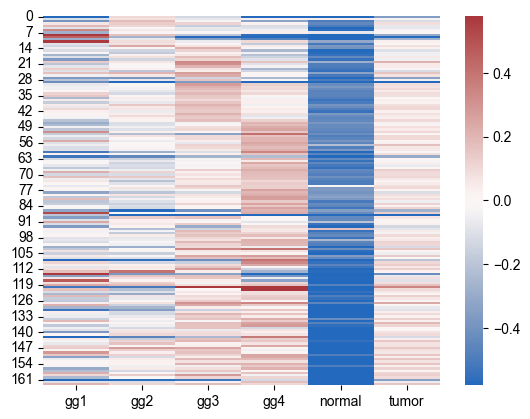

In [38]:
sns.heatmap(result[["gg1", "gg2", "gg3", "gg4", "normal","tumor"]], cmap="vlag", center=0,vmin=-0.58,vmax=0.58)